In [1]:
# All imports needed across the whole notebook
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torchaudio.transforms as T
import torchvision
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from sklearn.metrics import classification_report
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Count audio files per class to understand dataset size
dataset_path = Path('gunshot-audio-dataset')
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print('Dataset classes:')
for class_name in class_names:
    class_path = dataset_path / class_name
    file_count = len(list(class_path.glob('*.wav')))
    print(f'  {class_name}: {file_count} files')

Dataset classes:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [4]:
# Check whether files are mono or stereo
mono_count = 0
stereo_count = 0

for class_name in class_names:
    class_path = dataset_path / class_name
    for audio_file in class_path.glob('*.wav'):
        waveform, sr = torchaudio.load(audio_file)
        if waveform.shape[0] == 1:
            mono_count += 1
        else:
            stereo_count += 1

print(f'Mono files: {mono_count}')
print(f'Stereo files: {stereo_count}')

Mono files: 0
Stereo files: 851


In [5]:
# Count how many files exist at each sample rate
sample_rate_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    for audio_file in class_path.glob('*.wav'):
        waveform, sr = torchaudio.load(audio_file)
        sample_rate_counts[sr] = sample_rate_counts.get(sr, 0) + 1

for sr, count in sorted(sample_rate_counts.items()):
    print(f'{sr} Hz: {count} files')

44100 Hz: 197 files
48000 Hz: 654 files


In [6]:
# Check how long the audio files are across the dataset
durations = []
duration_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    for audio_file in class_path.glob('*.wav'):
        waveform, sr = torchaudio.load(audio_file)
        duration = waveform.shape[1] / sr
        durations.append(duration)
        key = round(duration, 2)
        duration_counts[key] = duration_counts.get(key, 0) + 1

print(f'Shortest duration: {min(durations):.2f}s')
print(f'Longest duration:  {max(durations):.2f}s')
print(f'Average duration:  {sum(durations)/len(durations):.2f}s')
print(f'\nUnique durations: {len(duration_counts)}')
for dur, count in sorted(duration_counts.items()):
    print(f'  {dur:.2f}s: {count} files')

if len(duration_counts) > 5:
    print('\nALERT: Durations vary significantly across files')

Shortest duration: 1.00s
Longest duration:  360.00s
Average duration:  3.04s

Unique durations: 7
  1.00s: 100 files
  2.00s: 745 files
  3.00s: 2 files
  4.00s: 1 files
  305.00s: 1 files
  320.00s: 1 files
  360.00s: 1 files

ALERT: Durations vary significantly across files


In [7]:
# Flag any significant class imbalance
class_file_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    class_file_counts[class_name] = len(list(class_path.glob('*.wav')))

max_count = max(class_file_counts.values())
min_count = min(class_file_counts.values())

print('Class distribution:')
for class_name, count in class_file_counts.items():
    print(f'  {class_name}: {count} files')

if max_count > 2 * min_count:
    print(f'\nClass imbalance detected: max={max_count}, min={min_count}')

Class distribution:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [8]:
# Individual preprocessing functions — each does exactly one thing
def convert_to_mono(waveform):
    if waveform.shape[0] > 1:
        return torch.mean(waveform, dim=0, keepdim=True)
    return waveform

def resample_audio(waveform, orig_sr, target_sr=48000):
    if orig_sr != target_sr:
        resampler = T.Resample(orig_sr, target_sr)
        return resampler(waveform)
    return waveform

def pad_or_crop(waveform, target_length):
    current_length = waveform.shape[1]
    if current_length < target_length:
        padding = target_length - current_length
        waveform = torch.nn.functional.pad(waveform, (0, padding))
    elif current_length > target_length:
        waveform = waveform[:, :target_length]
    return waveform

def apply_preemphasis(waveform, coef=0.97):
    return torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)

def normalize_audio(waveform):
    return waveform / (torch.max(torch.abs(waveform)) + 1e-8)

In [9]:
# Chain all preprocessing steps into one pipeline function
def preprocess_audio(file_path, target_sr=48000, target_duration=2.0):
    waveform, sr = torchaudio.load(file_path)
    waveform = convert_to_mono(waveform)
    waveform = resample_audio(waveform, sr, target_sr)
    target_length = int(target_sr * target_duration)
    waveform = pad_or_crop(waveform, target_length)
    waveform = apply_preemphasis(waveform)
    waveform = normalize_audio(waveform)
    return waveform, target_sr

In [10]:
# Preprocess all audio and write standardised 48kHz wav files
output_path = Path('processed-audio-48k')
output_path.mkdir(exist_ok=True)

print('Preprocessing audio files...')
for class_name in class_names:
    class_output_path = output_path / class_name
    class_output_path.mkdir(exist_ok=True)

    audio_files = list((dataset_path / class_name).glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = preprocess_audio(audio_file)
        torchaudio.save(class_output_path / audio_file.name, waveform, sr)

    print(f'  Processed {len(audio_files)} files for {class_name}')

print('Preprocessing complete')

Preprocessing audio files...
  Processed 98 files for AK-12
  Processed 72 files for AK-47
  Processed 100 files for IMI Desert Eagle
  Processed 100 files for M16
  Processed 99 files for M249
  Processed 100 files for M4
  Processed 100 files for MG-42
  Processed 100 files for MP5
  Processed 82 files for Zastava M92
Preprocessing complete


In [11]:
# Extract MFCC features from preprocessed audio and save as tensors
features_path = Path('features')
features_path.mkdir(exist_ok=True)

mfcc_transform = T.MFCC(
    sample_rate=48000,
    n_mfcc=40,
    melkwargs={'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
)

print('Extracting MFCC features...')
for class_name in class_names:
    class_features_path = features_path / class_name
    class_features_path.mkdir(exist_ok=True)

    audio_files = list((output_path / class_name).glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = torchaudio.load(audio_file)
        mfcc = mfcc_transform(waveform)
        torch.save(mfcc, class_features_path / f'{audio_file.stem}.pt')

    print(f'  Extracted features for {len(audio_files)} files in {class_name}')

print('Feature extraction complete')

Extracting MFCC features...
  Extracted features for 98 files in AK-12
  Extracted features for 72 files in AK-47
  Extracted features for 100 files in IMI Desert Eagle
  Extracted features for 100 files in M16
  Extracted features for 99 files in M249
  Extracted features for 100 files in M4
  Extracted features for 100 files in MG-42
  Extracted features for 100 files in MP5
  Extracted features for 82 files in Zastava M92
Feature extraction complete


In [12]:
# Map gun classes to integer labels — M16 and M4 share label 3 as M-Family
class_to_idx = {
    'AK-12': 0,
    'AK-47': 1,
    'IMI Desert Eagle': 2,
    'M16': 3,
    'M4': 3,
    'M249': 4,
    'MG-42': 5,
    'MP5': 6,
    'Zastava M92': 7
}

idx_to_class = {
    0: 'AK-12',
    1: 'AK-47',
    2: 'IMI Desert Eagle',
    3: 'M-Family',
    4: 'M249',
    5: 'MG-42',
    6: 'MP5',
    7: 'Zastava M92'
}

print('class_to_idx:')
for name, idx in class_to_idx.items():
    print(f'  {name} -> {idx}')
print('\nidx_to_class:')
for idx, name in idx_to_class.items():
    print(f'  {idx} -> {name}')

class_to_idx:
  AK-12 -> 0
  AK-47 -> 1
  IMI Desert Eagle -> 2
  M16 -> 3
  M4 -> 3
  M249 -> 4
  MG-42 -> 5
  MP5 -> 6
  Zastava M92 -> 7

idx_to_class:
  0 -> AK-12
  1 -> AK-47
  2 -> IMI Desert Eagle
  3 -> M-Family
  4 -> M249
  5 -> MG-42
  6 -> MP5
  7 -> Zastava M92


In [13]:
# Dataset that loads saved MFCC tensors and optionally augments them
class GunshotDataset(Dataset):
    def __init__(self, features_path, class_to_idx, augment=False):
        self.features_path = Path(features_path)
        self.class_to_idx = class_to_idx
        self.augment = augment
        self.samples = []

        for class_name, label in class_to_idx.items():
            class_path = self.features_path / class_name
            if class_path.exists():
                for feature_file in class_path.glob('*.pt'):
                    self.samples.append((feature_file, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feature_file, label = self.samples[idx]
        features = torch.load(feature_file, weights_only=True)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                features = features + torch.randn_like(features) * 0.01
            if torch.rand(1).item() < 0.5:
                shift = torch.randint(-10, 11, (1,)).item()
                features = torch.roll(features, shifts=shift, dims=-1)

        return features, label

full_dataset = GunshotDataset('features', class_to_idx, augment=False)
print(f'Total samples: {len(full_dataset)}')

Total samples: 851


In [14]:
# Split into 70/15/15 and build dataloaders — same split used for all three models
torch.manual_seed(42)

total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset_temp, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_dataset = GunshotDataset('features', class_to_idx, augment=True)
train_dataset.samples = [train_dataset.samples[i] for i in train_dataset_temp.indices]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Train: {train_size}, Val: {val_size}, Test: {test_size}')

Train: 595, Val: 127, Test: 129


In [15]:
# Compute inverse-frequency weights to handle class imbalance in the loss
class_counts = torch.zeros(8)
for _, label in full_dataset:
    class_counts[label] += 1

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

print('Class weights:')
for i, w in enumerate(class_weights):
    print(f'  {idx_to_class[i]}: {w.item():.4f}')

Class weights:
  AK-12: 0.1254
  AK-47: 0.1706
  IMI Desert Eagle: 0.1229
  M-Family: 0.0614
  M249: 0.1241
  MG-42: 0.1229
  MP5: 0.1229
  Zastava M92: 0.1498


In [16]:
# Custom CNN for gunshot classification
class GunshotCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(GunshotCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
# Instantiate GunshotCNN and move to the active device
cnn_model = GunshotCNN(num_classes=8).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'GunshotCNN initialized on {device}')
print(f'Trainable parameters: {total_params:,}')

GunshotCNN initialized on cuda
Trainable parameters: 169,288


In [18]:
# Optimizer, scheduler, and weighted loss for GunshotCNN
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005, weight_decay=2e-3)
cnn_scheduler = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=50, eta_min=1e-6)

print('Loss: Weighted CrossEntropyLoss')
print('Optimizer: Adam, lr=0.0005, weight_decay=2e-3')
print('Scheduler: CosineAnnealingLR, T_max=50, eta_min=1e-6')

Loss: Weighted CrossEntropyLoss
Optimizer: Adam, lr=0.0005, weight_decay=2e-3
Scheduler: CosineAnnealingLR, T_max=50, eta_min=1e-6


In [19]:
# Training hyperparameters and history containers for GunshotCNN
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

cnn_train_losses = []
cnn_train_accuracies = []
cnn_val_losses = []
cnn_val_accuracies = []

print(f'Training for up to {num_epochs} epochs with early stopping patience={patience}')

Training for up to 50 epochs with early stopping patience=5


In [20]:
# Train GunshotCNN with early stopping
for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        cnn_optimizer.zero_grad()
        outputs = cnn_model(features)
        loss = cnn_criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    cnn_train_losses.append(train_loss)
    cnn_train_accuracies.append(train_acc)

    cnn_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = cnn_model(features)
            loss = cnn_criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    cnn_val_losses.append(val_loss)
    cnn_val_accuracies.append(val_acc)

    cnn_scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | LR: {cnn_optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(cnn_model.state_dict(), 'best_gunshot_cnn.pth')
        print(f'  Saved best model with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('GunshotCNN training complete')

Epoch 1/50 | Train Loss: 1.9668 Acc: 22.69% | Val Loss: 1.8057 Acc: 22.83% | LR: 0.000500
  Saved best model with val_loss: 1.8057
Epoch 2/50 | Train Loss: 1.6257 Acc: 34.12% | Val Loss: 1.5333 Acc: 29.13% | LR: 0.000498
  Saved best model with val_loss: 1.5333
Epoch 3/50 | Train Loss: 1.4221 Acc: 37.98% | Val Loss: 1.3235 Acc: 34.65% | LR: 0.000496
  Saved best model with val_loss: 1.3235
Epoch 4/50 | Train Loss: 1.2580 Acc: 46.89% | Val Loss: 1.2138 Acc: 44.88% | LR: 0.000492
  Saved best model with val_loss: 1.2138
Epoch 5/50 | Train Loss: 1.1859 Acc: 50.59% | Val Loss: 1.1719 Acc: 49.61% | LR: 0.000488
  Saved best model with val_loss: 1.1719
Epoch 6/50 | Train Loss: 1.1094 Acc: 51.93% | Val Loss: 1.1074 Acc: 56.69% | LR: 0.000482
  Saved best model with val_loss: 1.1074
Epoch 7/50 | Train Loss: 0.9931 Acc: 60.17% | Val Loss: 1.0579 Acc: 56.69% | LR: 0.000476
  Saved best model with val_loss: 1.0579
Epoch 8/50 | Train Loss: 1.0418 Acc: 54.62% | Val Loss: 0.9859 Acc: 60.63% | LR: 0.

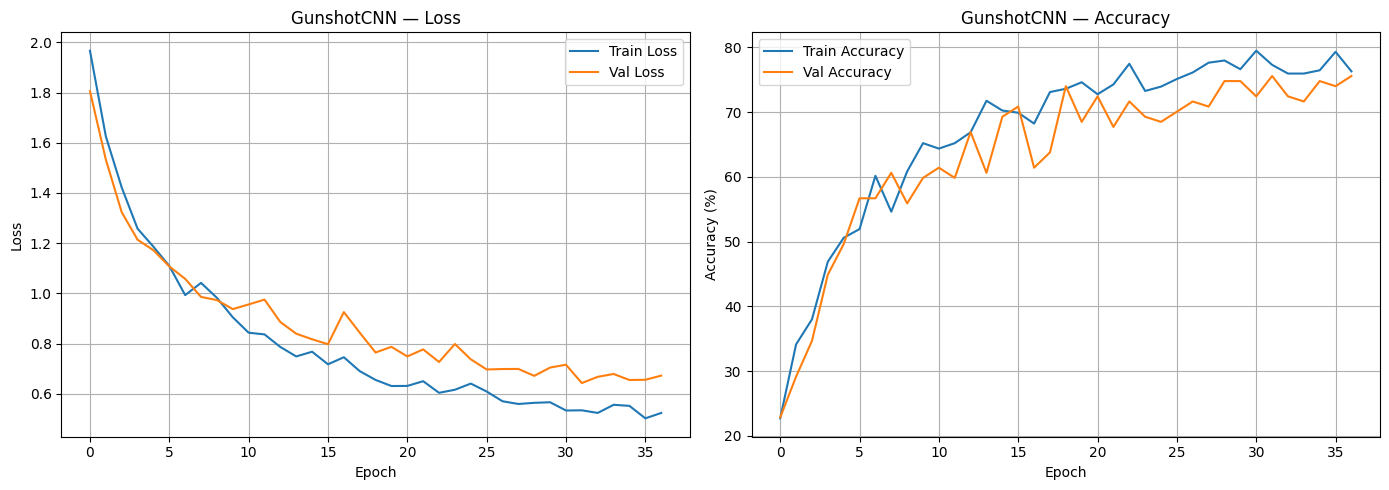

In [21]:
# Training curves for GunshotCNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_train_losses, label='Train Loss')
ax1.plot(cnn_val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('GunshotCNN — Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(cnn_train_accuracies, label='Train Accuracy')
ax2.plot(cnn_val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('GunshotCNN — Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# Load best weights and evaluate GunshotCNN on the validation set
cnn_model.load_state_dict(torch.load('best_gunshot_cnn.pth', weights_only=True))
cnn_model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = cnn_model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

print('GunshotCNN — Validation Set Classification Report:\n')
print(classification_report(val_labels, val_preds, target_names=[idx_to_class[i] for i in range(8)]))

GunshotCNN — Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        22
           AK-47       1.00      0.77      0.87        13
IMI Desert Eagle       0.58      0.69      0.63        16
        M-Family       0.76      0.54      0.63        24
            M249       0.64      0.94      0.76        17
           MG-42       0.67      0.53      0.59        15
             MP5       0.60      0.69      0.64        13
     Zastava M92       1.00      1.00      1.00         7

        accuracy                           0.76       127
       macro avg       0.78      0.77      0.77       127
    weighted avg       0.77      0.76      0.75       127



In [23]:
# Evaluate GunshotCNN on the held-out test set
cnn_model.eval()
test_correct = 0
test_total = 0
test_preds, test_labels_list = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = cnn_model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        test_preds.extend(predicted.cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

cnn_test_accuracy = 100 * test_correct / test_total
print(f'GunshotCNN Test Accuracy: {cnn_test_accuracy:.2f}%\n')
print(classification_report(test_labels_list, test_preds, target_names=[idx_to_class[i] for i in range(8)]))

GunshotCNN Test Accuracy: 77.52%

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        19
           AK-47       0.90      0.90      0.90        10
IMI Desert Eagle       0.64      0.69      0.67        13
        M-Family       0.75      0.69      0.72        35
            M249       0.57      0.73      0.64        11
           MG-42       0.73      0.79      0.76        14
             MP5       0.67      0.59      0.62        17
     Zastava M92       1.00      1.00      1.00        10

        accuracy                           0.78       129
       macro avg       0.78      0.80      0.79       129
    weighted avg       0.78      0.78      0.78       129



In [24]:
# EfficientNet-B0 adapted for single-channel MFCC input
class EfficientNetAudio(nn.Module):
    def __init__(self, num_classes=8):
        super(EfficientNetAudio, self).__init__()
        self.model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        # Freeze all parameters first
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace first conv to accept 1-channel input
        self.model.features[0][0] = nn.Conv2d(
            1, 32, kernel_size=3, stride=2, padding=1, bias=False
        )

        # Replace classifier head
        self.model.classifier = nn.Linear(1280, num_classes)

        # Unfreeze the modified layers
        for param in self.model.features[0][0].parameters():
            param.requires_grad = True
        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

In [25]:
# Instantiate EfficientNetAudio and report trainable parameter count
eff_model = EfficientNetAudio(num_classes=8).to(device)
trainable = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)
print(f'EfficientNetAudio initialized on {device}')
print(f'Trainable parameters: {trainable:,}')

EfficientNetAudio initialized on cuda
Trainable parameters: 10,536


In [26]:
# Optimizer, scheduler, and criterion for EfficientNet
eff_criterion = nn.CrossEntropyLoss(weight=class_weights)
eff_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, eff_model.parameters()),
    lr=0.0005, weight_decay=2e-3
)
eff_scheduler = optim.lr_scheduler.CosineAnnealingLR(eff_optimizer, T_max=50, eta_min=1e-6)

print('EfficientNet optimizer initialized')

EfficientNet optimizer initialized


In [27]:
# Training configuration for EfficientNet — fresh history and counters
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

eff_train_losses = []
eff_train_accuracies = []
eff_val_losses = []
eff_val_accuracies = []

print(f'Training EfficientNet for up to {num_epochs} epochs with patience={patience}')

Training EfficientNet for up to 50 epochs with patience=5


In [28]:
# Train EfficientNetAudio with early stopping
for epoch in range(num_epochs):
    eff_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        eff_optimizer.zero_grad()
        outputs = eff_model(features)
        loss = eff_criterion(outputs, labels)
        loss.backward()
        eff_optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    eff_train_losses.append(train_loss)
    eff_train_accuracies.append(train_acc)

    eff_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = eff_model(features)
            loss = eff_criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    eff_val_losses.append(val_loss)
    eff_val_accuracies.append(val_acc)

    eff_scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | LR: {eff_optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(eff_model.state_dict(), 'best_gunshot_efficientnet.pth')
        print(f'  Saved best model with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('EfficientNet training complete')

Epoch 1/50 | Train Loss: 1.9505 Acc: 27.39% | Val Loss: 1.8751 Acc: 29.92% | LR: 0.000500
  Saved best model with val_loss: 1.8751
Epoch 2/50 | Train Loss: 1.6798 Acc: 45.88% | Val Loss: 1.5966 Acc: 49.61% | LR: 0.000498
  Saved best model with val_loss: 1.5966
Epoch 3/50 | Train Loss: 1.5036 Acc: 55.29% | Val Loss: 1.4312 Acc: 57.48% | LR: 0.000496
  Saved best model with val_loss: 1.4312
Epoch 4/50 | Train Loss: 1.3843 Acc: 58.66% | Val Loss: 1.3227 Acc: 61.42% | LR: 0.000492
  Saved best model with val_loss: 1.3227
Epoch 5/50 | Train Loss: 1.3034 Acc: 61.18% | Val Loss: 1.2254 Acc: 62.99% | LR: 0.000488
  Saved best model with val_loss: 1.2254
Epoch 6/50 | Train Loss: 1.2107 Acc: 64.54% | Val Loss: 1.1634 Acc: 62.99% | LR: 0.000482
  Saved best model with val_loss: 1.1634
Epoch 7/50 | Train Loss: 1.1415 Acc: 64.03% | Val Loss: 1.0990 Acc: 66.93% | LR: 0.000476
  Saved best model with val_loss: 1.0990
Epoch 8/50 | Train Loss: 1.0765 Acc: 65.88% | Val Loss: 1.0512 Acc: 62.99% | LR: 0.

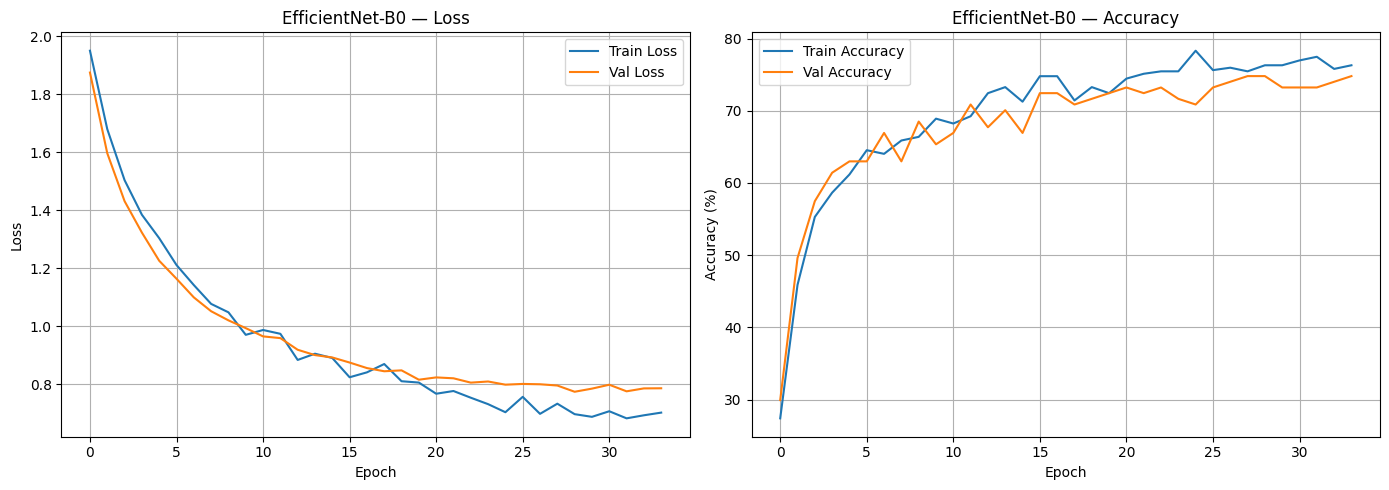

In [29]:
# Training curves for EfficientNet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eff_train_losses, label='Train Loss')
ax1.plot(eff_val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('EfficientNet-B0 — Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(eff_train_accuracies, label='Train Accuracy')
ax2.plot(eff_val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('EfficientNet-B0 — Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [30]:
# Load best EfficientNet weights and evaluate on validation set
eff_model.load_state_dict(torch.load('best_gunshot_efficientnet.pth', weights_only=True))
eff_model.eval()

eff_val_preds, eff_val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = eff_model(features)
        _, predicted = torch.max(outputs, 1)
        eff_val_preds.extend(predicted.cpu().numpy())
        eff_val_labels.extend(labels.cpu().numpy())

print('EfficientNet-B0 — Validation Set Classification Report:\n')
print(classification_report(eff_val_labels, eff_val_preds, target_names=[idx_to_class[i] for i in range(8)]))

EfficientNet-B0 — Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        22
           AK-47       0.73      0.85      0.79        13
IMI Desert Eagle       0.64      0.44      0.52        16
        M-Family       0.64      0.58      0.61        24
            M249       0.67      0.82      0.74        17
           MG-42       0.85      0.73      0.79        15
             MP5       0.69      0.69      0.69        13
     Zastava M92       0.70      1.00      0.82         7

        accuracy                           0.75       127
       macro avg       0.74      0.76      0.74       127
    weighted avg       0.75      0.75      0.74       127



In [31]:
# Evaluate EfficientNet on the test set
eff_model.eval()
test_correct = 0
test_total = 0
eff_test_preds, eff_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = eff_model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        eff_test_preds.extend(predicted.cpu().numpy())
        eff_test_labels.extend(labels.cpu().numpy())

eff_test_accuracy = 100 * test_correct / test_total
print(f'EfficientNet-B0 Test Accuracy: {eff_test_accuracy:.2f}%\n')
print(classification_report(eff_test_labels, eff_test_preds, target_names=[idx_to_class[i] for i in range(8)]))

EfficientNet-B0 Test Accuracy: 73.64%

                  precision    recall  f1-score   support

           AK-12       0.94      0.89      0.92        19
           AK-47       0.64      0.70      0.67        10
IMI Desert Eagle       0.53      0.77      0.62        13
        M-Family       0.79      0.66      0.72        35
            M249       0.62      0.73      0.67        11
           MG-42       0.71      0.71      0.71        14
             MP5       0.71      0.59      0.65        17
     Zastava M92       0.91      1.00      0.95        10

        accuracy                           0.74       129
       macro avg       0.73      0.76      0.74       129
    weighted avg       0.75      0.74      0.74       129



In [32]:
# MobileNetV2 adapted for single-channel MFCC input
class MobileNetAudio(nn.Module):
    def __init__(self, num_classes=8):
        super(MobileNetAudio, self).__init__()
        self.model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

        # Freeze all parameters first
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace first conv to accept 1-channel input
        self.model.features[0][0] = nn.Conv2d(
            1, 32, kernel_size=3, stride=2, padding=1, bias=False
        )

        # Replace classifier head
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

        # Unfreeze modified layers
        for param in self.model.features[0][0].parameters():
            param.requires_grad = True
        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

In [33]:
# Instantiate MobileNetAudio and report trainable parameter count
mob_model = MobileNetAudio(num_classes=8).to(device)
trainable = sum(p.numel() for p in mob_model.parameters() if p.requires_grad)
print(f'MobileNetAudio initialized on {device}')
print(f'Trainable parameters: {trainable:,}')

MobileNetAudio initialized on cuda
Trainable parameters: 10,536


In [34]:
# Optimizer, scheduler, and criterion for MobileNet
mob_criterion = nn.CrossEntropyLoss(weight=class_weights)
mob_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, mob_model.parameters()),
    lr=0.0005, weight_decay=2e-3
)
mob_scheduler = optim.lr_scheduler.CosineAnnealingLR(mob_optimizer, T_max=50, eta_min=1e-6)

print('MobileNet optimizer initialized')

MobileNet optimizer initialized


In [35]:
# Training configuration for MobileNet — fresh history and counters
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

mob_train_losses = []
mob_train_accuracies = []
mob_val_losses = []
mob_val_accuracies = []

print(f'Training MobileNet for up to {num_epochs} epochs with patience={patience}')

Training MobileNet for up to 50 epochs with patience=5


In [36]:
# Train MobileNetAudio with early stopping
for epoch in range(num_epochs):
    mob_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        mob_optimizer.zero_grad()
        outputs = mob_model(features)
        loss = mob_criterion(outputs, labels)
        loss.backward()
        mob_optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    mob_train_losses.append(train_loss)
    mob_train_accuracies.append(train_acc)

    mob_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = mob_model(features)
            loss = mob_criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    mob_val_losses.append(val_loss)
    mob_val_accuracies.append(val_acc)

    mob_scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | LR: {mob_optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(mob_model.state_dict(), 'best_gunshot_mobilenet.pth')
        print(f'  Saved best model with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('MobileNet training complete')

Epoch 1/50 | Train Loss: 2.0168 Acc: 23.19% | Val Loss: 1.9722 Acc: 33.07% | LR: 0.000500
  Saved best model with val_loss: 1.9722
Epoch 2/50 | Train Loss: 1.8212 Acc: 39.16% | Val Loss: 1.7475 Acc: 37.80% | LR: 0.000498
  Saved best model with val_loss: 1.7475
Epoch 3/50 | Train Loss: 1.6696 Acc: 46.89% | Val Loss: 1.6173 Acc: 44.09% | LR: 0.000496
  Saved best model with val_loss: 1.6173
Epoch 4/50 | Train Loss: 1.5252 Acc: 51.26% | Val Loss: 1.5467 Acc: 43.31% | LR: 0.000492
  Saved best model with val_loss: 1.5467
Epoch 5/50 | Train Loss: 1.4485 Acc: 55.13% | Val Loss: 1.4419 Acc: 47.24% | LR: 0.000488
  Saved best model with val_loss: 1.4419
Epoch 6/50 | Train Loss: 1.4161 Acc: 51.76% | Val Loss: 1.4060 Acc: 43.31% | LR: 0.000482
  Saved best model with val_loss: 1.4060
Epoch 7/50 | Train Loss: 1.3277 Acc: 57.48% | Val Loss: 1.3322 Acc: 51.18% | LR: 0.000476
  Saved best model with val_loss: 1.3322
Epoch 8/50 | Train Loss: 1.2692 Acc: 59.33% | Val Loss: 1.2623 Acc: 51.18% | LR: 0.

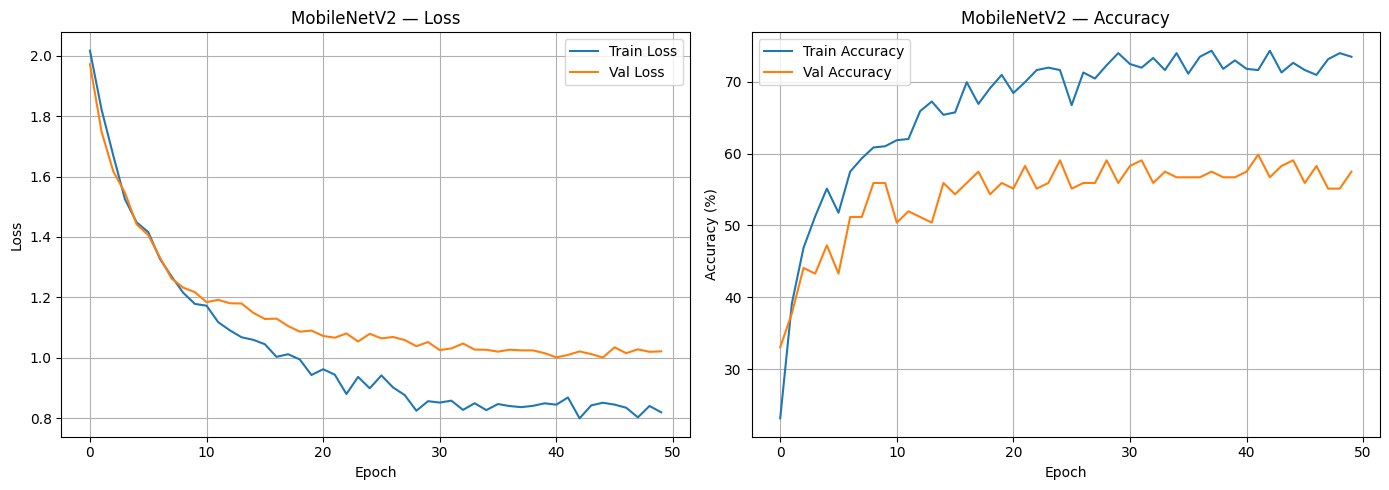

In [37]:
# Training curves for MobileNetV2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mob_train_losses, label='Train Loss')
ax1.plot(mob_val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MobileNetV2 — Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(mob_train_accuracies, label='Train Accuracy')
ax2.plot(mob_val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MobileNetV2 — Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [38]:
# Load best MobileNet weights and evaluate on validation set
mob_model.load_state_dict(torch.load('best_gunshot_mobilenet.pth', weights_only=True))
mob_model.eval()

mob_val_preds, mob_val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = mob_model(features)
        _, predicted = torch.max(outputs, 1)
        mob_val_preds.extend(predicted.cpu().numpy())
        mob_val_labels.extend(labels.cpu().numpy())

print('MobileNetV2 — Validation Set Classification Report:\n')
print(classification_report(mob_val_labels, mob_val_preds, target_names=[idx_to_class[i] for i in range(8)]))

MobileNetV2 — Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       0.95      0.91      0.93        22
           AK-47       0.83      0.77      0.80        13
IMI Desert Eagle       0.41      0.44      0.42        16
        M-Family       0.71      0.42      0.53        24
            M249       0.39      0.41      0.40        17
           MG-42       0.44      0.47      0.45        15
             MP5       0.32      0.54      0.40        13
     Zastava M92       1.00      1.00      1.00         7

        accuracy                           0.59       127
       macro avg       0.63      0.62      0.62       127
    weighted avg       0.63      0.59      0.60       127



In [39]:
# Evaluate MobileNet on the test set
mob_model.eval()
test_correct = 0
test_total = 0
mob_test_preds, mob_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = mob_model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        mob_test_preds.extend(predicted.cpu().numpy())
        mob_test_labels.extend(labels.cpu().numpy())

mob_test_accuracy = 100 * test_correct / test_total
print(f'MobileNetV2 Test Accuracy: {mob_test_accuracy:.2f}%\n')
print(classification_report(mob_test_labels, mob_test_preds, target_names=[idx_to_class[i] for i in range(8)]))

MobileNetV2 Test Accuracy: 70.54%

                  precision    recall  f1-score   support

           AK-12       1.00      0.95      0.97        19
           AK-47       0.62      0.80      0.70        10
IMI Desert Eagle       0.56      0.69      0.62        13
        M-Family       0.72      0.60      0.66        35
            M249       0.64      0.64      0.64        11
           MG-42       0.56      0.71      0.62        14
             MP5       0.57      0.47      0.52        17
     Zastava M92       1.00      1.00      1.00        10

        accuracy                           0.71       129
       macro avg       0.71      0.73      0.72       129
    weighted avg       0.72      0.71      0.71       129



In [40]:
# Side-by-side accuracy comparison of all three models
header = f"{'Model':<22} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10}"
print(header)
print('-' * len(header))
print(f"{'GunshotCNN':<22} {cnn_train_accuracies[-1]:>9.2f}% {cnn_val_accuracies[-1]:>9.2f}% {cnn_test_accuracy:>9.2f}%")
print(f"{'EfficientNet-B0':<22} {eff_train_accuracies[-1]:>9.2f}% {eff_val_accuracies[-1]:>9.2f}% {eff_test_accuracy:>9.2f}%")
print(f"{'MobileNetV2':<22} {mob_train_accuracies[-1]:>9.2f}% {mob_val_accuracies[-1]:>9.2f}% {mob_test_accuracy:>9.2f}%")

Model                   Train Acc    Val Acc   Test Acc
-------------------------------------------------------
GunshotCNN                 76.30%     75.59%     77.52%
EfficientNet-B0            76.30%     74.80%     73.64%
MobileNetV2                73.45%     57.48%     70.54%


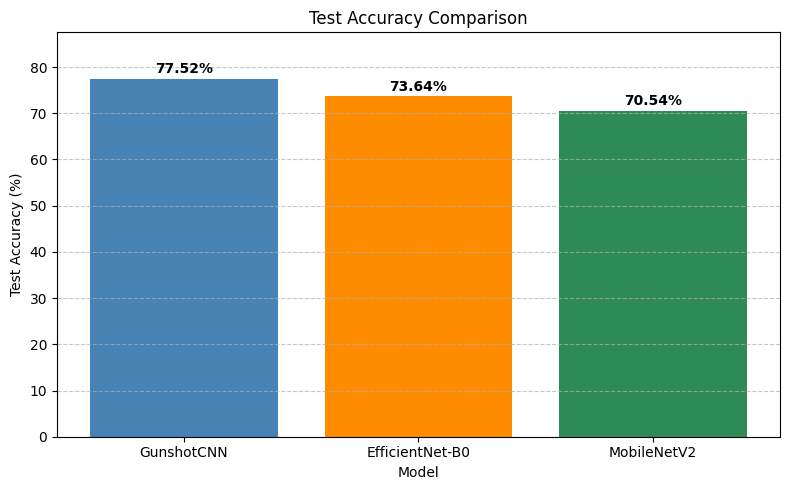

In [41]:
# Bar chart comparing test accuracy across all three models
model_names = ['GunshotCNN', 'EfficientNet-B0', 'MobileNetV2']
test_accuracies = [cnn_test_accuracy, eff_test_accuracy, mob_test_accuracy]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, test_accuracies, color=['steelblue', 'darkorange', 'seagreen'])

for bar, acc in zip(bars, test_accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Model')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison')
ax.set_ylim(0, max(test_accuracies) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [42]:
# Self-contained inference wrapper — stores everything needed to predict from a wav file
class AudioPipeline:
    def __init__(self, model, class_to_idx, idx_to_class):
        self.target_sr = 48000
        self.target_duration = 2.0
        self.n_mfcc = 40
        self.mfcc_params = {'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
        self.class_to_idx = class_to_idx
        self.idx_to_class = idx_to_class
        self.model = model.cpu()
        self.model.eval()

    def _convert_to_mono(self, waveform):
        if waveform.shape[0] > 1:
            return torch.mean(waveform, dim=0, keepdim=True)
        return waveform

    def _resample_audio(self, waveform, orig_sr):
        if orig_sr != self.target_sr:
            resampler = T.Resample(orig_sr, self.target_sr)
            return resampler(waveform)
        return waveform

    def _pad_or_crop(self, waveform, target_length):
        current_length = waveform.shape[1]
        if current_length < target_length:
            waveform = torch.nn.functional.pad(waveform, (0, target_length - current_length))
        elif current_length > target_length:
            waveform = waveform[:, :target_length]
        return waveform

    def _apply_preemphasis(self, waveform, coef=0.97):
        return torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)

    def _normalize_audio(self, waveform):
        return waveform / (torch.max(torch.abs(waveform)) + 1e-8)

    def _extract_mfcc(self, waveform):
        mfcc_transform = T.MFCC(
            sample_rate=self.target_sr,
            n_mfcc=self.n_mfcc,
            melkwargs=self.mfcc_params
        )
        return mfcc_transform(waveform)

    def predict(self, file_path):
        waveform, sr = torchaudio.load(file_path)
        waveform = self._convert_to_mono(waveform)
        waveform = self._resample_audio(waveform, sr)
        target_length = int(self.target_sr * self.target_duration)
        waveform = self._pad_or_crop(waveform, target_length)
        waveform = self._apply_preemphasis(waveform)
        waveform = self._normalize_audio(waveform)
        mfcc = self._extract_mfcc(waveform)
        mfcc = mfcc.unsqueeze(0)  # add batch dim, stays on cpu

        with torch.no_grad():
            output = self.model(mfcc)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        predicted_class = self.idx_to_class[predicted.item()]
        confidence_score = confidence.item() * 100
        return predicted_class, confidence_score

In [43]:
# Load best weights into each model, move to cpu, wrap in AudioPipeline, and save with joblib
cnn_model.load_state_dict(torch.load('best_gunshot_cnn.pth', weights_only=True))
eff_model.load_state_dict(torch.load('best_gunshot_efficientnet.pth', weights_only=True))
mob_model.load_state_dict(torch.load('best_gunshot_mobilenet.pth', weights_only=True))

cnn_pipeline = AudioPipeline(cnn_model, class_to_idx, idx_to_class)
eff_pipeline = AudioPipeline(eff_model, class_to_idx, idx_to_class)
mob_pipeline = AudioPipeline(mob_model, class_to_idx, idx_to_class)

joblib.dump(cnn_pipeline, 'gunshot_cnn_pipeline.joblib')
print('Saved gunshot_cnn_pipeline.joblib')

joblib.dump(eff_pipeline, 'gunshot_efficientnet_pipeline.joblib')
print('Saved gunshot_efficientnet_pipeline.joblib')

joblib.dump(mob_pipeline, 'gunshot_mobilenet_pipeline.joblib')
print('Saved gunshot_mobilenet_pipeline.joblib')

Saved gunshot_cnn_pipeline.joblib
Saved gunshot_efficientnet_pipeline.joblib
Saved gunshot_mobilenet_pipeline.joblib


In [44]:
# Load each pipeline from disk and run a test prediction to confirm they work
loaded_cnn = joblib.load('gunshot_cnn_pipeline.joblib')
loaded_eff = joblib.load('gunshot_efficientnet_pipeline.joblib')
loaded_mob = joblib.load('gunshot_mobilenet_pipeline.joblib')

sample_file = list(Path('gunshot-audio-dataset').rglob('*.wav'))[0]
print(f'Test file: {sample_file.name}\n')

for name, pipeline in [('GunshotCNN', loaded_cnn), ('EfficientNet-B0', loaded_eff), ('MobileNetV2', loaded_mob)]:
    pred_class, confidence = pipeline.predict(sample_file)
    print(f'{name:<22} Predicted: {pred_class:<20} Confidence: {confidence:.2f}%')

Test file: 3 (1).wav

GunshotCNN             Predicted: AK-12                Confidence: 92.35%
EfficientNet-B0        Predicted: AK-12                Confidence: 87.55%
MobileNetV2            Predicted: AK-12                Confidence: 83.32%


In [45]:
# Three conv blocks with batch norm — deeper version of GunshotCNN
class DeepGunshotCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(DeepGunshotCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout1 = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.pool(x)
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [46]:
# Instantiate DeepGunshotCNN and count trainable parameters
deep_model = DeepGunshotCNN(num_classes=8).to(device)
total_params = sum(p.numel() for p in deep_model.parameters())
trainable = sum(p.numel() for p in deep_model.parameters() if p.requires_grad)
print(f'DeepGunshotCNN — Total: {total_params:,}  Trainable: {trainable:,}')


DeepGunshotCNN — Total: 634,632  Trainable: 634,632


In [47]:
# Adam optimizer, cosine scheduler, weighted loss for DeepGunshotCNN
deep_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
deep_optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.0005, weight_decay=2e-3)
deep_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(deep_optimizer, T_max=50, eta_min=1e-6)


In [48]:
# Training config and empty history lists for DeepGunshotCNN
num_epochs = 50
patience = 5
patience_counter = 0
best_val_loss = float('inf')
deep_train_losses, deep_train_accuracies = [], []
deep_val_losses, deep_val_accuracies = [], []


In [49]:
# Training loop with early stopping — saves best weights to best_gunshot_deep_cnn.pth
for epoch in range(num_epochs):
    deep_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        deep_optimizer.zero_grad()
        outputs = deep_model(features)
        loss = deep_criterion(outputs, labels)
        loss.backward()
        deep_optimizer.step()
        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total
    deep_train_losses.append(train_loss)
    deep_train_accuracies.append(train_acc)

    deep_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = deep_model(features)
            loss = deep_criterion(outputs, labels)
            val_running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total
    deep_val_losses.append(val_loss)
    deep_val_accuracies.append(val_acc)

    deep_scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(deep_model.state_dict(), 'best_gunshot_deep_cnn.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')


Epoch  10 | Train Loss: 0.7744  Train Acc: 63.70%  Val Loss: 0.8366  Val Acc: 64.57%
Early stopping at epoch 17


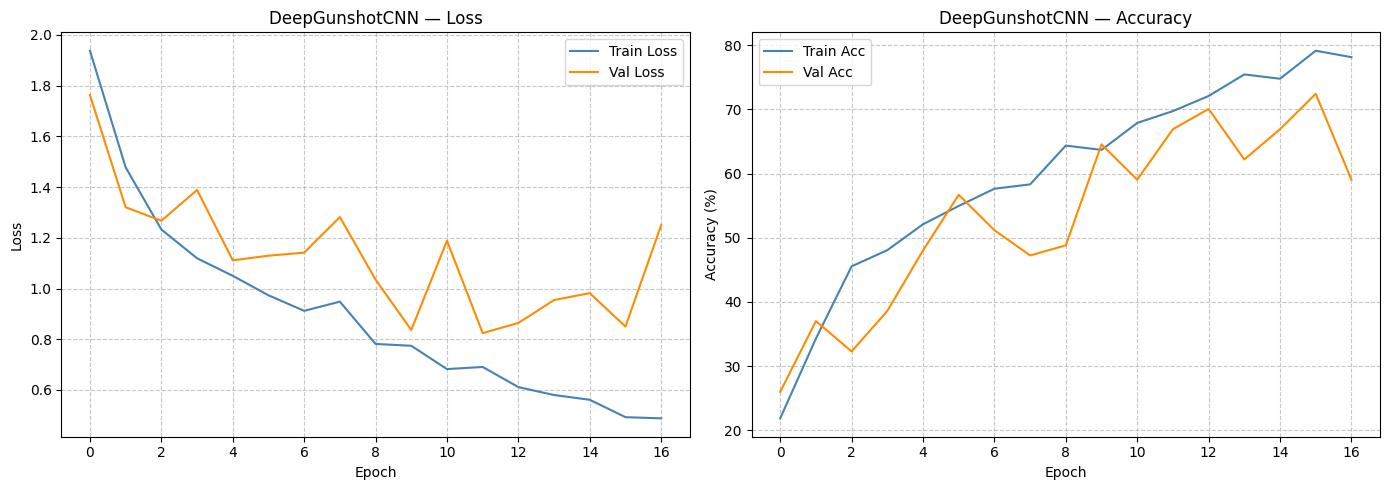

In [50]:
# Training curves for DeepGunshotCNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(deep_train_losses, label='Train Loss', color='steelblue')
ax1.plot(deep_val_losses, label='Val Loss', color='darkorange')
ax1.set_title('DeepGunshotCNN — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.7)

ax2.plot(deep_train_accuracies, label='Train Acc', color='steelblue')
ax2.plot(deep_val_accuracies, label='Val Acc', color='darkorange')
ax2.set_title('DeepGunshotCNN — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [51]:
# Load best weights and evaluate on validation set
deep_model.load_state_dict(torch.load('best_gunshot_deep_cnn.pth', weights_only=True))
deep_model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = deep_model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.numpy())

target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print('DeepGunshotCNN — Validation Classification Report')
print(classification_report(val_labels, val_preds, target_names=target_names))


DeepGunshotCNN — Validation Classification Report
                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        22
           AK-47       1.00      0.77      0.87        13
IMI Desert Eagle       0.57      0.50      0.53        16
        M-Family       0.70      0.58      0.64        24
            M249       0.62      0.76      0.68        17
           MG-42       0.53      0.53      0.53        15
             MP5       0.17      0.23      0.19        13
     Zastava M92       1.00      1.00      1.00         7

        accuracy                           0.67       127
       macro avg       0.70      0.67      0.68       127
    weighted avg       0.70      0.67      0.68       127



In [52]:
# Evaluate on test set and store result as deep_test_accuracy
deep_model.eval()
test_correct = 0
test_total = 0
deep_test_preds, deep_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = deep_model(features)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)
        deep_test_preds.extend(predicted.cpu().numpy())
        deep_test_labels.extend(labels.cpu().numpy())

deep_test_accuracy = 100 * test_correct / test_total
print(f'DeepGunshotCNN Test Accuracy: {deep_test_accuracy:.2f}%')
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(classification_report(deep_test_labels, deep_test_preds, target_names=target_names))


DeepGunshotCNN Test Accuracy: 73.64%
                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        19
           AK-47       1.00      0.90      0.95        10
IMI Desert Eagle       0.62      0.62      0.62        13
        M-Family       0.79      0.66      0.72        35
            M249       0.46      0.55      0.50        11
           MG-42       0.61      0.79      0.69        14
             MP5       0.50      0.53      0.51        17
     Zastava M92       1.00      1.00      1.00        10

        accuracy                           0.74       129
       macro avg       0.75      0.75      0.75       129
    weighted avg       0.75      0.74      0.74       129



In [53]:
# ViT-B/16 adapted for single-channel MFCC input — upsample and repeat channels in forward
import torch.nn.functional as F
from torchvision.models import vit_b_16, ViT_B_16_Weights

class ViTAudio(nn.Module):
    def __init__(self, num_classes=8):
        super(ViTAudio, self).__init__()
        self.vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        for param in self.vit.parameters():
            param.requires_grad = False
        self.vit.heads = nn.Linear(768, num_classes)
        for param in self.vit.heads.parameters():
            param.requires_grad = True

    def forward(self, x):
        # x: [batch, 1, 40, 188] — upsample to 224x224, repeat to 3 channels
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        x = x.repeat(1, 3, 1, 1)
        return self.vit(x)


In [54]:
# Instantiate ViTAudio and count trainable parameters
vit_model = ViTAudio(num_classes=8).to(device)
total_params = sum(p.numel() for p in vit_model.parameters())
trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT-B/16 — Total: {total_params:,}  Trainable: {trainable:,}')


ViT-B/16 — Total: 85,804,808  Trainable: 6,152


In [55]:
# Adam with lower lr for ViT, cosine scheduler, weighted loss
vit_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
vit_optimizer = torch.optim.Adam(vit_model.parameters(), lr=0.0001, weight_decay=1e-3)
vit_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=50, eta_min=1e-7)


In [56]:
# Training config and history lists for ViT
num_epochs = 50
patience = 5
patience_counter = 0
best_val_loss = float('inf')
vit_train_losses, vit_train_accuracies = [], []
vit_val_losses, vit_val_accuracies = [], []


In [57]:
# Training loop with early stopping — saves best weights to best_gunshot_vit.pth
for epoch in range(num_epochs):
    vit_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        vit_optimizer.zero_grad()
        outputs = vit_model(features)
        loss = vit_criterion(outputs, labels)
        loss.backward()
        vit_optimizer.step()
        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total
    vit_train_losses.append(train_loss)
    vit_train_accuracies.append(train_acc)

    vit_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = vit_model(features)
            loss = vit_criterion(outputs, labels)
            val_running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total
    vit_val_losses.append(val_loss)
    vit_val_accuracies.append(val_acc)

    vit_scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(vit_model.state_dict(), 'best_gunshot_vit.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')


Epoch  10 | Train Loss: 1.6706  Train Acc: 41.51%  Val Loss: 1.7284  Val Acc: 37.01%
Epoch  20 | Train Loss: 1.4752  Train Acc: 50.08%  Val Loss: 1.5459  Val Acc: 46.46%
Epoch  30 | Train Loss: 1.3862  Train Acc: 52.10%  Val Loss: 1.4547  Val Acc: 48.82%
Epoch  40 | Train Loss: 1.3467  Train Acc: 52.44%  Val Loss: 1.4241  Val Acc: 49.61%
Epoch  50 | Train Loss: 1.3471  Train Acc: 54.29%  Val Loss: 1.4195  Val Acc: 50.39%


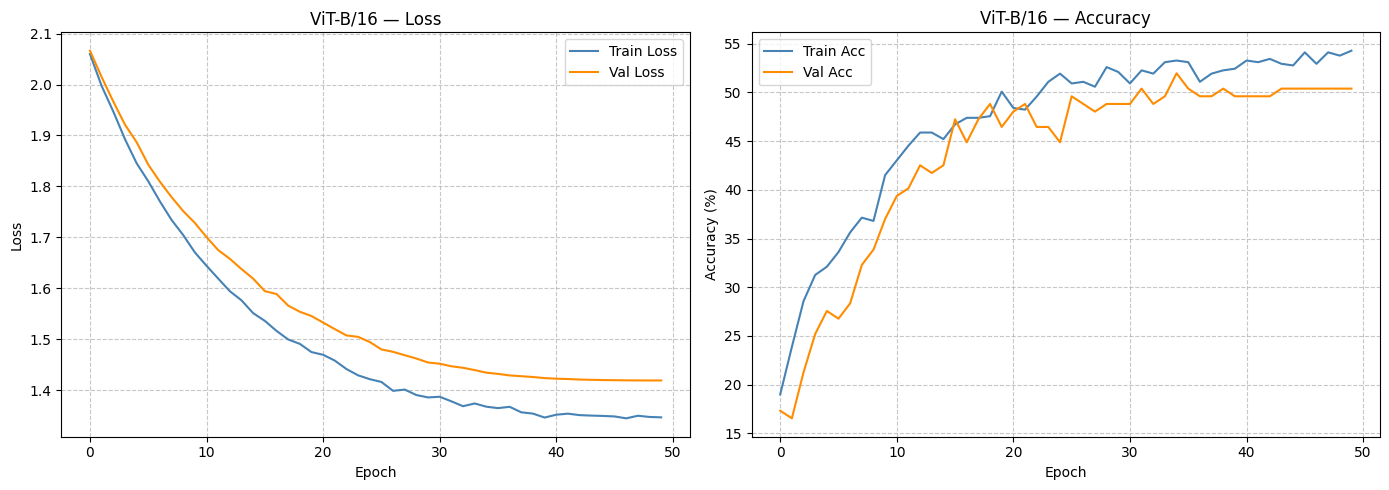

In [58]:
# Training curves for ViT-B/16
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(vit_train_losses, label='Train Loss', color='steelblue')
ax1.plot(vit_val_losses, label='Val Loss', color='darkorange')
ax1.set_title('ViT-B/16 — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.7)

ax2.plot(vit_train_accuracies, label='Train Acc', color='steelblue')
ax2.plot(vit_val_accuracies, label='Val Acc', color='darkorange')
ax2.set_title('ViT-B/16 — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [59]:
# Load best weights and evaluate on validation set
vit_model.load_state_dict(torch.load('best_gunshot_vit.pth', weights_only=True))
vit_model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = vit_model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.numpy())

target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print('ViT-B/16 — Validation Classification Report')
print(classification_report(val_labels, val_preds, target_names=target_names))


ViT-B/16 — Validation Classification Report
                  precision    recall  f1-score   support

           AK-12       0.85      0.50      0.63        22
           AK-47       0.70      0.54      0.61        13
IMI Desert Eagle       0.40      0.62      0.49        16
        M-Family       0.40      0.08      0.14        24
            M249       0.62      0.59      0.61        17
           MG-42       0.48      0.67      0.56        15
             MP5       0.35      0.54      0.42        13
     Zastava M92       0.41      1.00      0.58         7

        accuracy                           0.50       127
       macro avg       0.53      0.57      0.50       127
    weighted avg       0.54      0.50      0.48       127



In [60]:
# Evaluate on test set and store result as vit_test_accuracy
vit_model.eval()
test_correct = 0
test_total = 0
vit_test_preds, vit_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = vit_model(features)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)
        vit_test_preds.extend(predicted.cpu().numpy())
        vit_test_labels.extend(labels.cpu().numpy())

vit_test_accuracy = 100 * test_correct / test_total
print(f'ViT-B/16 Test Accuracy: {vit_test_accuracy:.2f}%')
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(classification_report(vit_test_labels, vit_test_preds, target_names=target_names))


ViT-B/16 Test Accuracy: 54.26%
                  precision    recall  f1-score   support

           AK-12       0.83      0.79      0.81        19
           AK-47       0.40      0.40      0.40        10
IMI Desert Eagle       0.39      0.69      0.50        13
        M-Family       0.59      0.29      0.38        35
            M249       0.55      0.55      0.55        11
           MG-42       0.53      0.64      0.58        14
             MP5       0.35      0.41      0.38        17
     Zastava M92       0.77      1.00      0.87        10

        accuracy                           0.54       129
       macro avg       0.55      0.60      0.56       129
    weighted avg       0.56      0.54      0.53       129



In [61]:
# Updated comparison table with all five models
header = f"{'Model':<22} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10}"
print(header)
print('-' * len(header))
print(f"{'GunshotCNN':<22} {cnn_train_accuracies[-1]:>9.2f}% {cnn_val_accuracies[-1]:>9.2f}% {cnn_test_accuracy:>9.2f}%")
print(f"{'EfficientNet-B0':<22} {eff_train_accuracies[-1]:>9.2f}% {eff_val_accuracies[-1]:>9.2f}% {eff_test_accuracy:>9.2f}%")
print(f"{'MobileNetV2':<22} {mob_train_accuracies[-1]:>9.2f}% {mob_val_accuracies[-1]:>9.2f}% {mob_test_accuracy:>9.2f}%")
print(f"{'DeepGunshotCNN':<22} {deep_train_accuracies[-1]:>9.2f}% {deep_val_accuracies[-1]:>9.2f}% {deep_test_accuracy:>9.2f}%")
print(f"{'ViT-B/16':<22} {vit_train_accuracies[-1]:>9.2f}% {vit_val_accuracies[-1]:>9.2f}% {vit_test_accuracy:>9.2f}%")


Model                   Train Acc    Val Acc   Test Acc
-------------------------------------------------------
GunshotCNN                 76.30%     75.59%     77.52%
EfficientNet-B0            76.30%     74.80%     73.64%
MobileNetV2                73.45%     57.48%     70.54%
DeepGunshotCNN             78.15%     59.06%     73.64%
ViT-B/16                   54.29%     50.39%     54.26%


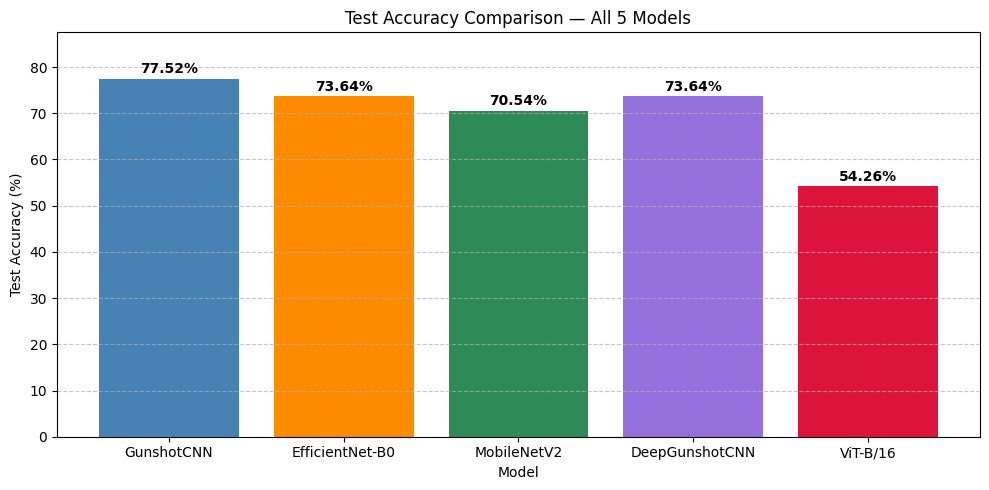

In [62]:
# Bar chart comparing test accuracy of all five models
model_names_all = ['GunshotCNN', 'EfficientNet-B0', 'MobileNetV2', 'DeepGunshotCNN', 'ViT-B/16']
test_accuracies_all = [cnn_test_accuracy, eff_test_accuracy, mob_test_accuracy, deep_test_accuracy, vit_test_accuracy]
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names_all, test_accuracies_all, color=colors)

for bar, acc in zip(bars, test_accuracies_all):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Model')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison — All 5 Models')
ax.set_ylim(0, max(test_accuracies_all) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [63]:
# Load best weights for new models, wrap in AudioPipeline, save with joblib
deep_model.load_state_dict(torch.load('best_gunshot_deep_cnn.pth', weights_only=True))
vit_model.load_state_dict(torch.load('best_gunshot_vit.pth', weights_only=True))

deep_pipeline = AudioPipeline(deep_model, class_to_idx, idx_to_class)
vit_pipeline = AudioPipeline(vit_model, class_to_idx, idx_to_class)

joblib.dump(deep_pipeline, 'gunshot_deep_cnn_pipeline.joblib')
print('Saved gunshot_deep_cnn_pipeline.joblib')

joblib.dump(vit_pipeline, 'gunshot_vit_pipeline.joblib')
print('Saved gunshot_vit_pipeline.joblib')


Saved gunshot_deep_cnn_pipeline.joblib
Saved gunshot_vit_pipeline.joblib


In [64]:
# Load both new pipelines from disk and run a test prediction to confirm they work
loaded_deep = joblib.load('gunshot_deep_cnn_pipeline.joblib')
loaded_vit = joblib.load('gunshot_vit_pipeline.joblib')

sample_file = list(Path('gunshot-audio-dataset').rglob('*.wav'))[0]
print(f'Test file: {sample_file.name}\n')

for name, pipeline in [('DeepGunshotCNN', loaded_deep), ('ViT-B/16', loaded_vit)]:
    pred_class, confidence = pipeline.predict(sample_file)
    print(f'{name:<22} Predicted: {pred_class:<20} Confidence: {confidence:.2f}%')


Test file: 3 (1).wav

DeepGunshotCNN         Predicted: AK-12                Confidence: 87.08%
ViT-B/16               Predicted: AK-12                Confidence: 27.30%
